Crime Trends Overtime


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Crime_Data_from_2020_to_Present.csv")

In [5]:
# Checking the Head
df.head()

,division_number,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,modus_operandi,...,status,status_description,crime_code_1,crime_code_2,crime_code_3,crime_code_4,location,cross_street,latitude,longitude
0,10304468,2020-01-08,2020-01-08 22:30:00,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,0444 0913,...,AO,Adult Other,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,2020-01-02,2020-01-01 03:30:00,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,0416 1822 1414,...,IC,Invest Cont,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,2020-04-14,2020-02-13 12:00:00,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,1501,...,AA,Adult Arrest,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,2020-01-01,2020-01-01 17:30:00,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0329 1402,...,IC,Invest Cont,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,2020-01-01,2020-01-01 04:15:00,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,...,IC,Invest Cont,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468


In [6]:
# Check dataset shape
print("Shape:", df.shape)

# Check column names
print(df.columns)

Shape: (852950, 27)
Index(['division_number', 'date_reported', 'date_occurred', 'area',
       'area_name', 'reporting_district', 'part', 'crime_code',
       'crime_description', 'modus_operandi', 'victim_age', 'victim_sex',
       'victim_descent', 'premise_code', 'premise_description', 'weapon_code',
       'weapon_description', 'status', 'status_description', 'crime_code_1',
       'crime_code_2', 'crime_code_3', 'crime_code_4', 'location',
       'cross_street', 'latitude', 'longitude'],
      dtype='object')


In [11]:
# Convert DATE OCC to datetime
df['date_occurred'] = pd.to_datetime(df['date_occurred'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['date_occurred'])

In [12]:
# Extract year and month
df['Year'] = df['date_occurred'].dt.year
df['Month'] = df['date_occurred'].dt.month

# Create Year-Month column
df['YearMonth'] = df['date_occurred'].dt.to_period('M')

In [13]:
# Count crimes per month
monthly_crimes = df.groupby('YearMonth').size()

# Convert PeriodIndex to timestamp
monthly_crimes.index = monthly_crimes.index.to_timestamp()

# Display first few values
print(monthly_crimes.head())

YearMonth
2020-01-01    18496
2020-02-01    17255
2020-03-01    16165
2020-04-01    15683
2020-05-01    17204
Freq: MS, dtype: int64


In [18]:
# Smooth trend using rolling average
rolling_avg = monthly_crimes.rolling(window=3).mean()

In [19]:
rolling_avg

,0
YearMonth,
2020-01-01,NaN
2020-02-01,NaN
2020-03-01,17305.333333
2020-04-01,16367.666667
2020-05-01,16350.666667
2020-06-01,16640.333333
2020-07-01,17119.666667
2020-08-01,17009.666667
2020-09-01,16544.666667


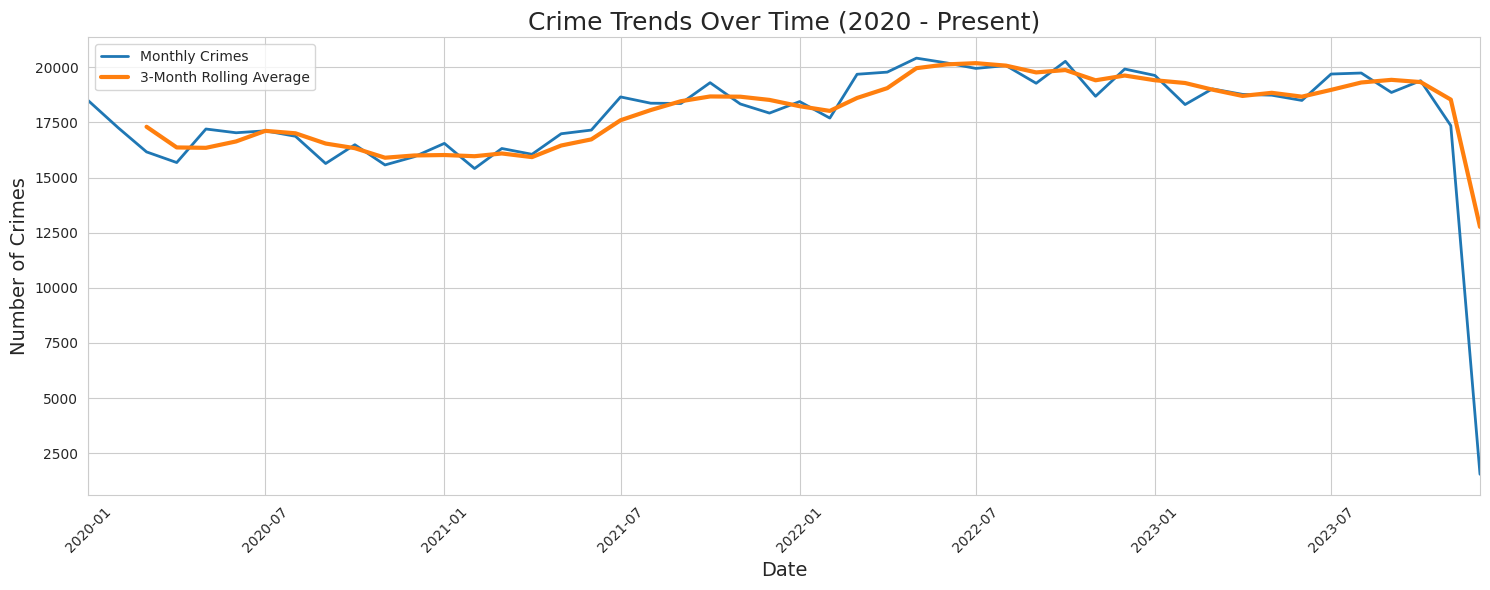

In [27]:
# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(15,6))

# Plot monthly crime trend
plt.plot(
    monthly_crimes.index,
    monthly_crimes.values,
    label='Monthly Crimes',
    linewidth=2
)

# Plot rolling average
plt.plot(
    rolling_avg.index,
    rolling_avg.values,
    label='3-Month Rolling Average',
    linewidth=3
)

# Title
plt.title(
    "Crime Trends Over Time (2020 - Present)",
    fontsize=18
)

# Axis labels
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)

# Rotate dates
plt.xticks(rotation=45)

# Remove left/right padding
plt.xlim(
    monthly_crimes.index.min(),
    monthly_crimes.index.max()
)

# Add legend
plt.legend()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()